> **Chapter 15, Part 2** | Engineering lens. **Focus:** partition assets by date, record what is materialized, and make backfills idempotent so a rerun is a no-op.

# Partitions and Backfills

Real pipelines do not materialize one giant table; they materialize one slice per day (or per hour, per region, per tenant). Each slice is a **partition**. The two properties that matter:

- **Backfill**: materialize a range of past partitions that are missing.
- **Idempotency**: materializing a partition that already exists does nothing. Rerun the backfill and it is a no-op.

Cron has neither. It reran everything, every time, and double-counted. We fix both with a materialization log: a record of which (asset, partition) pairs already exist.

In [1]:
# The tiny orchestrator we build across 15.1-15.3, collected into one cell.
from collections import deque
from dataclasses import dataclass
from typing import Callable, Optional


@dataclass
class Asset:
    name: str
    deps: list
    compute: Callable
    partitioned: bool = False


class AssetGraph:
    def __init__(self):
        self.assets = {}

    def add(self, asset):
        self.assets[asset.name] = asset
        return self

    def _downstream(self):
        down = {n: [] for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in down:
                    down[d].append(n)
        return down

    def topological_order(self):
        indeg = {n: 0 for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in indeg:
                    indeg[n] += 1
        down = self._downstream()
        q = deque(sorted(n for n, k in indeg.items() if k == 0))
        order = []
        while q:
            n = q.popleft()
            order.append(n)
            for m in sorted(down[n]):
                indeg[m] -= 1
                if indeg[m] == 0:
                    q.append(m)
        if len(order) != len(self.assets):
            stuck = sorted(n for n in self.assets if n not in order)
            raise ValueError("cycle detected among assets: " + ", ".join(stuck))
        return order

    def _needed(self, targets):
        need = set()
        stack = list(targets)
        while stack:
            n = stack.pop()
            if n in need or n not in self.assets:   # ignore refs outside the graph
                continue
            need.add(n)
            stack.extend(self.assets[n].deps)
        return need

    def materialize(self, targets=None, log=None, partition=None, verbose=True):
        order = self.topological_order()
        if targets is not None:
            need = self._needed(targets)
            order = [n for n in order if n in need]
        results = {}
        for n in order:
            tag = " [" + str(partition) + "]" if partition is not None else ""
            if log is not None and log.is_materialized(n, partition):
                results[n] = log.value(n, partition)
                if verbose:
                    print("  skip   " + n + tag + " (already materialized)")
                continue
            inputs = {d: results.get(d) for d in self.assets[n].deps}
            value = self.assets[n].compute(inputs)
            results[n] = value
            if log is not None:
                log.record(n, partition, value)
            if verbose:
                print("  build  " + n + tag)
        return results


class MaterializationLog:
    def __init__(self):
        self.store = {}

    def is_materialized(self, name, partition=None):
        return (name, partition) in self.store

    def record(self, name, partition=None, value=None):
        self.store[(name, partition)] = value

    def value(self, name, partition=None):
        return self.store[(name, partition)]


def backfill(graph, target, partitions, log, verbose=True):
    report = {"materialized": [], "skipped": []}
    order = [n for n in graph.topological_order() if n in graph._needed([target])]
    for p in partitions:
        for n in order:
            if log.is_materialized(n, p):
                report["skipped"].append((n, p))
                continue
            inputs = {d: (log.value(d, p) if log.is_materialized(d, p) else None)
                      for d in graph.assets[n].deps}
            log.record(n, p, graph.assets[n].compute(inputs))
            report["materialized"].append((n, p))
    return report


def blast_radius(graph, failed):
    down = graph._downstream()
    seen, stack = set(), list(down[failed])
    while stack:
        n = stack.pop()
        if n in seen:
            continue
        seen.add(n)
        stack.extend(down[n])
    return seen


@dataclass
class RetryPolicy:
    max_attempts: int = 1


def materialize_with_failures(graph, failing=None, retry=None, verbose=True):
    failing = failing or {}
    retry = retry or RetryPolicy()
    order = graph.topological_order()
    status, results, attempts_used = {}, {}, {}
    for n in order:
        if any(status.get(d) in ("failed", "skipped") for d in graph.assets[n].deps):
            status[n] = "skipped"
            if verbose:
                print("  skip    " + n + " (upstream failed)")
            continue
        attempts, ok = 0, False
        while attempts < retry.max_attempts:
            attempts += 1
            if attempts <= failing.get(n, 0):
                if verbose:
                    print("  retry   " + n + " attempt " + str(attempts) + " failed")
                continue
            ok = True
            break
        attempts_used[n] = attempts
        if ok:
            inputs = {d: results.get(d) for d in graph.assets[n].deps}
            results[n] = graph.assets[n].compute(inputs)
            status[n] = "materialized"
            if verbose:
                print("  build   " + n + " (attempt " + str(attempts) + ")")
        else:
            status[n] = "failed"
            if verbose:
                print("  FAIL    " + n + " (exhausted " + str(retry.max_attempts) + " attempts)")
    return status, results, attempts_used


print("orchestrator core ready:", len([Asset, AssetGraph, MaterializationLog,
      backfill, blast_radius, RetryPolicy, materialize_with_failures]), "building blocks")

orchestrator core ready: 7 building blocks


The log is the whole trick. `materialize` checks it before computing an asset, and skips anything already recorded. Build a partitioned pipeline and materialize a single day.

In [2]:
g = AssetGraph()
g.add(Asset("ingest", [], lambda i: 1, partitioned=True))
g.add(Asset("clean", ["ingest"], lambda i: 1, partitioned=True))
g.add(Asset("rollup", ["clean"], lambda i: 1, partitioned=True))

log = MaterializationLog()
print("materialize 2026-06-01:")
g.materialize(log=log, partition="2026-06-01")

materialize 2026-06-01:
  build  ingest [2026-06-01]
  build  clean [2026-06-01]
  build  rollup [2026-06-01]


{'ingest': 1, 'clean': 1, 'rollup': 1}

## Validation V003: idempotency

Materialize the same day again. Every asset should skip, because the log already has it. No compute runs, nothing double-counts.

In [3]:
print("re-materialize the same day:")
g.materialize(log=log, partition="2026-06-01")

re-materialize the same day:
  skip   ingest [2026-06-01] (already materialized)
  skip   clean [2026-06-01] (already materialized)
  skip   rollup [2026-06-01] (already materialized)


{'ingest': 1, 'clean': 1, 'rollup': 1}

## Backfill a week, then rerun it

`backfill` walks a list of partitions and materializes only what is missing. Backfill a full week; every (asset, day) is new. Then backfill an overlapping range and watch most of it skip.

In [4]:
week = [f"2026-06-0{d}" for d in range(1, 8)]   # 01..07
log2 = MaterializationLog()

report = backfill(g, "rollup", week, log2, verbose=False)
print(f"first backfill of {len(week)} days:")
print(f"  materialized: {len(report['materialized'])} (asset, day) pairs")
print(f"  skipped:      {len(report['skipped'])}")

# Now backfill days 05..10. Days 05-07 already exist; only 08-10 are new.
again = backfill(g, "rollup", [f"2026-06-0{d}" if d < 10 else "2026-06-10"
                               for d in range(5, 11)], log2, verbose=False)
print()
print("overlapping backfill of days 05..10:")
print(f"  materialized: {len(again['materialized'])} (the 3 genuinely new days x 3 assets)")
print(f"  skipped:      {len(again['skipped'])} (already done)")

first backfill of 7 days:
  materialized: 21 (asset, day) pairs
  skipped:      0

overlapping backfill of days 05..10:
  materialized: 9 (the 3 genuinely new days x 3 assets)
  skipped:      9 (already done)


## The backfill heatmap

A partition grid makes the state legible: assets down the side, days across the top, filled where materialized. This is the same view the studio's Lab 2 animates, and the same view Dagster shows in its asset catalog.

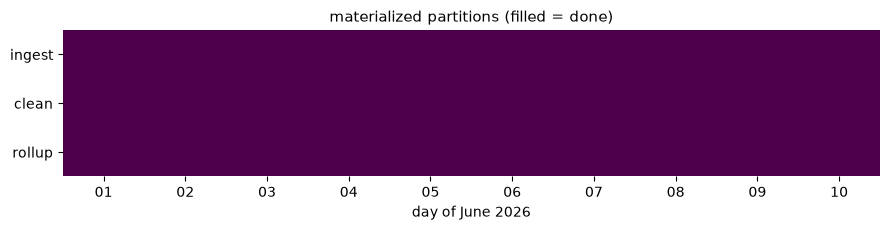

days 08-10 were filled by the second backfill; 01-07 by the first.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

assets = g.topological_order()
days = [f"2026-06-{d:02d}" for d in range(1, 11)]
grid = np.zeros((len(assets), len(days)))
for (name, part) in log2.store:
    if name in assets and part in days:
        grid[assets.index(name), days.index(part)] = 1

fig, ax = plt.subplots(figsize=(9, 2.4))
ax.imshow(grid, aspect="auto", cmap="BuPu", vmin=0, vmax=1)
ax.set_xticks(range(len(days)))
ax.set_xticklabels([d[-2:] for d in days])
ax.set_yticks(range(len(assets)))
ax.set_yticklabels(assets)
ax.set_xlabel("day of June 2026")
ax.set_title("materialized partitions (filled = done)", fontsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

print("days 08-10 were filled by the second backfill; 01-07 by the first.")

Idempotent backfills are the single property that turns a fragile cron pile into something you can rerun without fear. Next: sensors, so the pipeline reacts to the world instead of waiting for a clock.